## Running example from the readme


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

def generate_gp_samples_with_library(n_groups, n_observations_per_group, n_dimensions, time_points, length_scale=1.0):
    """
    Generate multidimensional GP samples using scikit-learn.
    Each dimension has the same underlying process.
    """
    kernel = RBF(length_scale=length_scale)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8)

    gp_sample_constant = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()

    samples = []
    for _ in range(n_groups):
        group_samples = []
        for _ in tqdm(range(n_observations_per_group)):
            # Generate independent samples for each dimension
            gp_samples_per_dim = []
            for _ in range(n_dimensions):
                gp_sample = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()
                gp_samples_per_dim.append(gp_sample)
            # Stack the samples to form a multidimensional sample
            gp_samples_multidim = np.stack(gp_samples_per_dim, axis=-1)
            group_samples.append(gp_samples_multidim)
        samples.append(np.array(group_samples))

    return samples

# Parameters
n_groups = 1
n_observations_per_group = 5000
n_dimensions = 4
n_time_points = 30
time_points = np.linspace(0, 10, n_time_points)
length_scale = 1.5

# Generate GP samples
gp_samples = generate_gp_samples_with_library(
    n_groups=n_groups,
    n_observations_per_group=n_observations_per_group,
    n_dimensions=n_dimensions,
    time_points=time_points,
    length_scale=length_scale
)

if False:
    # Plot example
    for dim in range(n_dimensions):
        for group_idx in range(n_groups):
            plt.figure()
            for observation in gp_samples[group_idx]:
                plt.plot(time_points, observation[:, dim], label=f"Dim {dim + 1}")
            plt.title(f"Group {group_idx + 1} Observations for Dimension {dim + 1}")
            plt.xlabel("Time")
            plt.ylabel("Value")
            plt.legend()
            plt.show()


100%|██████████| 5000/5000 [00:02<00:00, 1912.65it/s]


In [3]:
n_new_dims = 6
Proj = np.random.uniform(size = (n_dimensions, n_new_dims))#.reshape(1,1,n_dimensions, n_new_dims)
X_ori = gp_samples[0] @ Proj

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def get_errors(gpvae, X, num_samples=10, p=0.2, plots = False):
    """
    Computes reconstruction errors and normalized errors for original and corrupted data
    using a Gaussian Process Variational Autoencoder (GPVAE).

    Parameters:
    - gpvae: The GPVAE model instance.
    - X: The input data (numpy array or torch tensor).
    - num_samples: Number of samples to draw for the stochastic encoding.
    - p: Probability of missing data (for corruption).

    Returns:
    - A list containing:
        - error: Mean squared error on the original data.
        - error_corrupted: Mean absolute error on the corrupted data.
        - normalized_error_corrupted_imp: Normalized error for imputed (missing) data.
        - normalized_error_corrupted_recon: Normalized error for observed data.
    """

    # Ensure X is a numpy array and handle NaNs by replacing them with zeros
    X = np.nan_to_num(X, nan=0)

    # Introduce missing completely at random (MCAR) corruption
    X_corrupted = mcar(X, p)  # Assuming mcar function is defined elsewhere
    X_corrupted = np.nan_to_num(X_corrupted, nan=0)

    # Convert data to torch tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    X_corrupted_tensor = torch.tensor(X_corrupted, dtype=torch.float32)

    # Encode and decode the original data
    z = gpvae.model.backbone.encode(X_tensor).mean
    X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()

    # Encode and decode the corrupted data with sampling
    z_corrupted = gpvae.model.backbone.encode(X_corrupted_tensor).rsample(sample_shape=(num_samples,))
    X_recon_corrupted = np.array([gpvae.model.backbone.decode(z).mean.detach().numpy() for z in z_corrupted])

    # Compute mean squared error for the original data (excluding zeros)
    mask_nonzero = X != 0
    error = np.mean((X[mask_nonzero] - X_recon[mask_nonzero]) ** 2)

    # Compute mean absolute error for the corrupted data
    error_list = []
    for x_recon in X_recon_corrupted:
        mask_observed = X_corrupted != 0
        error_sample = np.mean(np.abs(X[mask_observed] - x_recon[mask_observed]))
        error_list.append(error_sample)
    error_corrupted = np.mean(error_list)

    # Compute standard deviation across the reconstructed samples
    X_recon_corrupted_std = np.std(X_recon_corrupted, axis=0)

    # Compute normalized error
    eps = 1e-1  # Small constant to avoid division by zero
    abs_errors = np.mean(np.abs(X_recon_corrupted - X), axis=0)
    normalized_error = abs_errors / (X_recon_corrupted_std + eps)

    # Compute normalized errors for imputed (missing) and observed data
    mask_missing = X_corrupted == 0
    mask_observed = ~mask_missing
    normalized_error_corrupted_imp = normalized_error[mask_missing].mean()
    normalized_error_corrupted_recon = normalized_error[mask_observed].mean()

    error_corrupted_imp = abs_errors[mask_missing].mean()
    error_corrupted_recon = abs_errors[mask_observed].mean()

    if plots:


        plt.plot(X_recon[0])
        plt.plot(X[0],'o')
        plt.plot(X_corrupted[0],'+')
        plt.show()

        # Plot distributions of errors, standard deviations, and normalized errors
        plt.figure(figsize=(12, 6))
        plt.hist((normalized_error * X_recon_corrupted_std).flatten(), bins=50, density=True, alpha=0.5, label='Errors')
        plt.hist(X_recon_corrupted_std.flatten(), bins=50, density=True, alpha=0.5, label='Standard Deviations')
        plt.hist(normalized_error.flatten(), bins=100, density=True, alpha=0.5, label='Normalized Errors')
        plt.legend()
        plt.xlim([0, 30])
        plt.ylim([0, 1.2])
        plt.title('Distribution of Errors and Standard Deviations')
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.show()
    
        # Plot reconstructed samples and original data for the first instance
        X_plot = X.copy()
        X_plot[X_plot == 0] = np.nan  # Replace zeros with NaN for plotting
        xx = np.arange(X.shape[1])
    
        plt.figure(figsize=(12, 6))
        for i in range(min(10, num_samples)):
            plt.plot(X_recon_corrupted[i, 0], alpha=0.3)
        plt.plot(xx, X_plot[0], '+', label='Original Data')
        plt.plot(xx, X_corrupted[0], 'o', label='Corrupted Data')
        plt.legend()
        plt.title('Reconstruction of the First Sample')
        plt.xlabel('Feature Index')
        plt.ylabel('Value')
        plt.show()
    
        # Detailed plotting for missing data
        indices_missing = np.where(mask_missing.flatten())[0][:100]  # Get indices of missing data
        fig, ax = plt.subplots(2, figsize=(18, 8))
    
        # Plot reconstructed values for missing data
        ax[0].plot(X_recon_corrupted[:, mask_missing].reshape(num_samples, -1)[:, :100].T, color='k', alpha=0.5)
        ax[0].plot(X[mask_missing].flatten()[:100], 'o', label='Original Missing Data')
        ax[0].set_title('Reconstructed Missing Data')
        ax[0].set_xlabel('Sample Index')
        ax[0].set_ylabel('Value')
        ax[0].legend()
    
        # Plot normalized errors for missing data
        ax[1].semilogy(normalized_error[mask_missing].flatten()[:100])
        ax[1].set_title('Normalized Errors for Missing Data')
        ax[1].set_xlabel('Sample Index')
        ax[1].set_ylabel('Normalized Error')
        plt.tight_layout()
        plt.show()

    return [error, error_corrupted, normalized_error_corrupted_imp, normalized_error_corrupted_recon, error_corrupted_imp, error_corrupted_recon]


In [5]:
err_p030 = get_errors(gpvae, X_normalized, p = .05, plots = False)
print(err_p030)

NameError: name 'gpvae' is not defined

In [7]:
list_p_dataset = [0.1, 0.3, 0.5]
list_gamma = [1e-2, 1e0, 1e2]


import torch
import os

#err_p030 = get_errors(gpvae, X)

errors = {}

device = 'cpu'

for p_dataset in list_p_dataset:
    for gamma in list_gamma:
        X_normalized = (X_ori - X_ori.mean(axis=(0,1)).reshape(1,1,-1)) / X_ori.std(axis=(0,1)).reshape(1,1,-1)
        X = mcar(X_normalized, p_dataset)  # randomly hold out 10% observed values as ground truth
        X[X!=X] = 0
        dataset = {'X' : X}

        gpvae = GP_VAE(n_steps = dataset['X'].shape[1], 
                    n_features = dataset['X'].shape[2], 
                    latent_size = 6, 
                    epochs = 50, 
                    batch_size = 8,
                    beta = 1., 
                    K = 20,  
                    encoder_sizes = (128,64), 
                    decoder_sizes = (32,32),
                    optimizer = Adam() #lr = 1e-4
                    )

    
        gpvae.model.backbone.gamma = gamma
        gpvae.model.backbone.alpha = 1e1
        gpvae.model.backbone.p = 0.05
        # Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
        #with torch.autograd.set_detect_anomaly(False):
        gpvae.model.backbone.device = device
        try:
            gpvae.fit(dataset)  # train the model on the dataset
        except:
            print('did,t converge')

        errors[f'p_dataset_{p_dataset}-gamma_{gamma}'] = get_errors(gpvae, X_normalized)
        print(errors)

        os.rename('latent_plots/losses.png', f'latent_plots/losses_p_dataset_{p_dataset}-gamma_{gamma}.png')


NameError: name 'mcar' is not defined

In [8]:
from pygrinder import mcar
# Normalize

X_normalized = (X_ori - X_ori.mean(axis=(0,1)).reshape(1,1,-1)) / X_ori.std(axis=(0,1)).reshape(1,1,-1)[:100]
X = mcar(X_normalized.copy(), 0.3)  # randomly hold out 10% observed values as ground truth
X[X!=X] = 0
dataset = {'X' : X}

len_dataset = len(dataset['X'])
cut = int(len_dataset*0.7)
dataset_train, dataset_val = {'X':dataset['X'][:cut]}, {'X':dataset['X'][cut:], 'X_ori':X_normalized[cut:]}

#plt.plot(X_ori[1]);

2025-02-20 10:43:39 [INFO]: No given device, using default device: cpu
2025-02-20 10:43:39 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-02-20 10:43:39 [INFO]: GP_VAE initialized with the given hyperparameters, the number of trainable parameters: 12,502


Model dimensions is:
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=64, out_features=8, bias=True)
  (logvar_layer): Linear(in_features=64, out_features=8, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=6, bias=True)
  )
)


2025-02-20 10:43:47 [INFO]: Epoch 001 - training loss: 31.0665, validation loss: 0.1976
2025-02-20 10:43:54 [INFO]: Epoch 002 - training loss: 9.0990, validation loss: 0.1508
2025-02-20 10:44:03 [INFO]: Epoch 003 - training loss: 6.3649, validation loss: 0.1083
2025-02-20 10:44:11 [INFO]: Epoch 004 - training loss: 4.7030, validation loss: 0.0948
2025-02-20 10:44:20 [INFO]: Epoch 005 - training loss: 4.0054, validation loss: 0.0863


Plotting latent series and reconstruction...


2025-02-20 10:44:29 [INFO]: Epoch 006 - training loss: 3.5106, validation loss: 0.0789
2025-02-20 10:44:37 [INFO]: Epoch 007 - training loss: 3.1218, validation loss: 0.0735
2025-02-20 10:44:46 [INFO]: Epoch 008 - training loss: 2.8463, validation loss: 0.0695
2025-02-20 10:44:53 [INFO]: Epoch 009 - training loss: 2.6333, validation loss: 0.0653
2025-02-20 10:45:02 [INFO]: Epoch 010 - training loss: 2.4447, validation loss: 0.0627


...

2025-02-20 10:49:45 [INFO]: Epoch 046 - training loss: 1.2860, validation loss: 0.0447
2025-02-20 10:49:53 [INFO]: Epoch 047 - training loss: 1.2768, validation loss: 0.0440
2025-02-20 10:50:00 [INFO]: Epoch 048 - training loss: 1.2535, validation loss: 0.0436
2025-02-20 10:50:08 [INFO]: Epoch 049 - training loss: 1.2342, validation loss: 0.0428
2025-02-20 10:50:16 [INFO]: Epoch 050 - training loss: 1.2200, validation loss: 0.0440


Plotting latent series and reconstruction...


2025-02-20 10:50:25 [INFO]: Epoch 051 - training loss: 1.1939, validation loss: 0.0428
2025-02-20 10:50:36 [INFO]: Epoch 052 - training loss: 1.1824, validation loss: 0.0432
2025-02-20 10:50:46 [INFO]: Epoch 053 - training loss: 1.1583, validation loss: 0.0424
2025-02-20 10:50:53 [INFO]: Epoch 054 - training loss: 1.1438, validation loss: 0.0433
2025-02-20 10:51:00 [INFO]: Epoch 055 - training loss: 1.1236, validation loss: 0.0427
2025-02-20 10:51:07 [INFO]: Epoch 056 - training loss: 1.1093, validation loss: 0.0447


Plotting latent series and reconstruction...


2025-02-20 10:51:14 [INFO]: Epoch 057 - training loss: 1.0881, validation loss: 0.0430
2025-02-20 10:51:23 [INFO]: Epoch 058 - training loss: 1.0773, validation loss: 0.0426
2025-02-20 10:51:31 [INFO]: Epoch 059 - training loss: 1.0706, validation loss: 0.0433
2025-02-20 10:51:39 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2025-02-20 10:51:39 [INFO]: Finished training. The best model is from epoch#53.


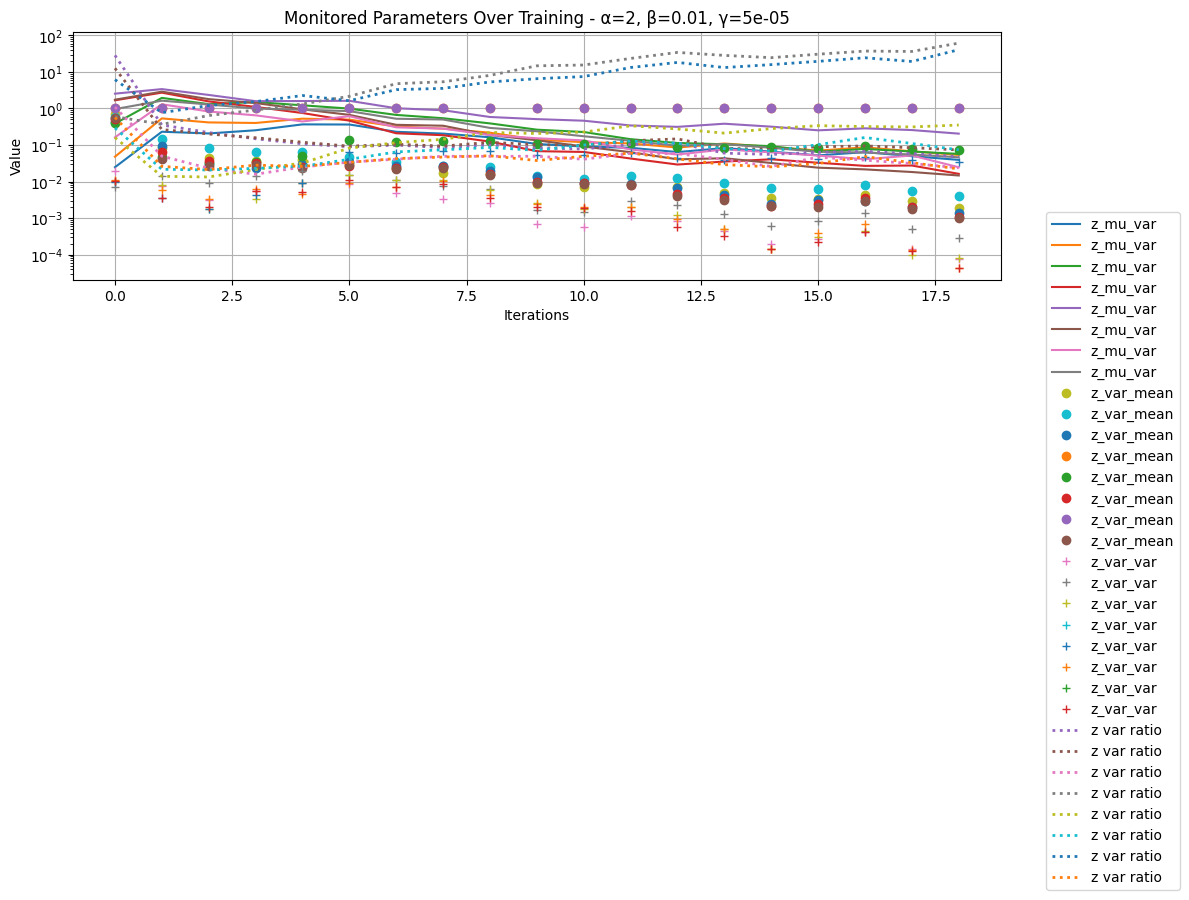

In [14]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

gpvae = GP_VAE(n_steps = dataset['X'].shape[1], 
            n_features = dataset['X'].shape[2], 
            latent_size = 8, 
            epochs = 200, 
            batch_size = 32,
            beta = 1., 
            K = 20,  
            encoder_sizes = (128,64), 
            decoder_sizes = (32,32),
            optimizer = Adam(lr = 5*1e-4, weight_decay = 0.05) #lr = 1e-4,
            patience = 50
            )

gpvae.model.backbone.alpha = 2
gpvae.model.backbone.beta = 1e-2
gpvae.model.backbone.gamma = 5 * 1e-5
gpvae.model.backbone.noise_sigma = 1e-2
gpvae.model.backbone.sampling = False
gpvae.model.backbone.use_mean = True
gpvae.model.backbone.noise_std = 1e-2
gpvae.model.backbone.detach = False





gpvae.model.backbone.p = 0.3
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
#with torch.autograd.set_detect_anomaly(False):
gpvae.model.backbone.device = 'cpu'
gpvae.fit(dataset_train, dataset_val)  # train the model on the dataset

In [21]:
gpvae.fit(dataset_train, dataset_val)  # train the model on the dataset

2024-12-02 18:39:39 [INFO]: Epoch 001 - training loss: 1.1623, validation loss: 0.0539
2024-12-02 18:39:47 [INFO]: Epoch 002 - training loss: 1.1685, validation loss: 0.0525
2024-12-02 18:39:55 [INFO]: Epoch 003 - training loss: 1.1547, validation loss: 0.0582
2024-12-02 18:40:02 [INFO]: Epoch 004 - training loss: 1.1514, validation loss: 0.0533
2024-12-02 18:40:09 [INFO]: Epoch 005 - training loss: 1.1547, validation loss: 0.0507
2024-12-02 18:40:16 [INFO]: Epoch 006 - training loss: 1.1570, validation loss: 0.0493
2024-12-02 18:40:24 [INFO]: Epoch 007 - training loss: 1.1566, validation loss: 0.0507
2024-12-02 18:40:27 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2024-12-02 18:40:27 [INFO]: Finished training. The best model is from epoch#6.


In [ ]:
gpvae.model.backbone.alpha = 1 
gpvae.model.backbone.beta = 1 
gpvae.model.backbone.gamma = 5 * 1e-2
gpvae.model.backbone.sampling = False

In [15]:
get_errors(gpvae, X_ori, num_samples = 20, p = .1)

[0.016465601207912826,
 0.0817443699447056,
 1.8935923488376076,
 0.7672846773836115,
 0.3181118492088615,
 0.08174436994470559]

In [ ]:
qz_x = gpvae.model.backbone.encode(torch.tensor(X_recon_3).float())
z = qz_x.mean
X_recon_4 = gpvae.model.backbone.decode(z).mean.detach().numpy()
plt.plot(X_recon_2[0])
plt.plot(X_recon[0],'o')
plt.show();

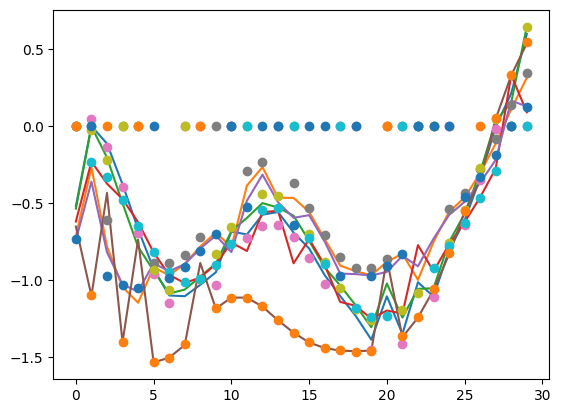

In [16]:
qz_x = gpvae.model.backbone.encode(torch.tensor(X).float())
z = qz_x.mean
X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
plt.plot(X_recon[0])
plt.plot(X[0],'o')
plt.show();

In [ ]:
#gpvae.model.backbone.sampling = True
#gpvae.model.backbone.alpha = 1e1

gpvae.fit(dataset)  # train the model on the dataset

#gpvae.model.backbone.alpha = 1e2

In [ ]:
gpvae.model.backbone.alpha = 1e0 # - 1e-
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
#gpvae.model.backbone.alpha = 1 - 1e-1 #1 - 1e-
#gpvae.model.backbone.gamma = 1e-7 # 0#.1
#gpvae.model.backbone.alpha = 1e-4
for param in gpvae.model.backbone.decoder.parameters():
    param.requires_grad = True
gpvae.model.backbone.p = .1
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
gpvae.model.backbone.train_decoder = False
for param in gpvae.model.backbone.decoder.parameters():
    param.requires_grad = False
gpvae.alpha = 1 - 1e-3
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
gpvae.model.backbone.alpha = 1 - 1e-1 #.005
gpvae.model.backbone.p = 0.3
gpvae.beta = 100
gpvae.fit(dataset)  # train the model on the dataset

In [17]:
## define tests to evaluate convergence of AE

## Assess reconstruction error
import torch

def get_errors(gpvae, X):

    X_corrupted = mcar(X, 0.3)
    X_corrupted[X_corrupted!=X_corrupted] = 0
    
    z = gpvae.model.backbone.encoder(torch.tensor(X).float()).mean
    X_recon = gpvae.model.backbone.decoder(z).mean
    
    z_corrupted = gpvae.model.backbone.encoder(torch.tensor(X_corrupted).float()).rsample()#sample_shape = torch.Size([10])
    X_recon_corrupted = gpvae.model.backbone.decoder(z_corrupted).mean
    
    error = (torch.tensor(X).float() - X_recon).pow(2)[X!=0].mean().item()
    
    error_corrupted = (torch.tensor(X).float() - X_recon_corrupted).pow(2)[X_corrupted!=0].mean().item()
    
    error_imputation_corrupted = (torch.tensor(X).float() - X_recon_corrupted).pow(2)[X_corrupted==0].mean().item()
    
    print(error, error_corrupted, error_imputation_corrupted)

    return [error, error_corrupted, error_imputation_corrupted]

err_p030 = get_errors(gpvae, X)


0.0028400945011526346 0.003595655085518956 1.2574275732040405


In [ ]:
errs = {}

errs[f'p_dataset_{p_dataset}_p_model_{p_model}_gamma_{gamma}'] = get_errors(gpvae, X)

In [ ]:
gpvae.model.backbone.p = 0.1

#gpvae.model.backbone.load_state_dict(torch.load('model_weights2.pth'))
gpvae.epochs = 100
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
# Assume 'model' is your neural network instance
torch.save(gpvae.model.backbone.state_dict(), 'model_weights_p030.pth')

#gpvae_backup = gpvae

In [ ]:
import torch
#gpvae.model.backbone.load_state_dict(torch.load('model_weights_p005.pth'))

gpvae.model.backbone.train_decoder = False
for param in gpvae.model.backbone.decoder.parameters():
    param.requires_grad = True
gpvae.epochs = 100
    
gpvae.model.backbone.p = 0.1
gpvae.model.backbone.gamma = 1e-3
gpvae.model.backbone.sampling = True


# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset

In [18]:
# Assume 'model' is your neural network instance
torch.save(gpvae.model.backbone.state_dict(), 'model_weights_2025.pth')

#gpvae_backup = gpvae

In [20]:
gpvae.model.backbone.load_state_dict(torch.load('model_weights_2025.pth'))


#for param in gpvae.model.backbone.decoder.parameters():
#    param.requires_grad = False
    
#gpvae.model.backbone.p = 0.3
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
#gpvae.fit(dataset)  # train the model on the dataset

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_92715/964246670.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpvae.model.backbone.load_state_dict(torch.loa

<All keys matched successfully>

In [ ]:
#gpvae.model.backbone.load_state_dict(torch.load('model_weights2.pth'))


for param in gpvae.model.backbone.decoder.parameters():
    param.requires_grad = False
    
gpvae.model.backbone.p = 0.3
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset

## RUN THIS

In [ ]:
gpvae.model.backbone.p = 0.1

gpvae.fit(dataset)  # train the model on the dataset

In [23]:
## Assess reconstruction error
import torch

z = gpvae.model.backbone.encoder(torch.tensor(X).float()).mean
X_recon = gpvae.model.backbone.decoder(z).mean

error = (torch.tensor(X).float() - X_recon).pow(2)[X!=0].mean()

print(error)

tensor(0.0028, grad_fn=<MeanBackward0>)


In [ ]:
for param in gpvae.model.backbone.decoder.parameters():
    param.requires_grad = False
    
gpvae.model.backbone.p = 0.1
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
gpvae.model.backbone.p = .3
gpvae.model.backbone.sampling = True
gpvae.fit(dataset)  # train the model on the dataset

In [24]:
import gpytorch
import torch
with gpytorch.settings.cholesky_jitter(1e-4):
    with torch.autograd.set_detect_anomaly(True):
        gpvae.fit_kernel(dataset)  # train the model on the dataset


fitting kernel


Epoch 1/20: 157it [00:09, 16.39it/s]


Epoch 1/20: Average Loss = 0.028304


Epoch 2/20: 157it [00:10, 15.65it/s]


Epoch 2/20: Average Loss = 0.028395


...

Epoch 3/20: Average Loss = 0.028563


Epoch 4/20: 157it [00:10, 14.43it/s]


Epoch 4/20: Average Loss = 0.028479


Epoch 5/20: 149it [00:10, 14.72it/s]


KeyboardInterrupt: 

In [ ]:
gpvae.gp.gp_models[0].covar_module.outputscale


In [ ]:
help(gpvae.gp.gp_models[0].covar_module)


In [ ]:
import torch
x = torch.ones((8,48))
gpvae.gp.gp_models[0](x)

In [ ]:
gpvae.gp._fit_kernel

In [ ]:
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/gpvae_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/gpvae_physionet2012.pypots")  # reload the serialized model file for following imputation or training

In [ ]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GPVAE
from pypots.utils.metrics import calc_mae
gpvae = GPVAE(n_steps=48, n_features=37, latent_size = 12, epochs=10)
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/gpvae_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/gpvae_physionet2012.pypots")  # reload the serialized model file for following imputation or training

In [ ]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import SAITS
from pypots.utils.metrics import calc_mae
gpvae = SAITS(n_steps=48, n_features=37, n_layers=2, d_model=256, n_heads=4, d_k=64, d_v=64, d_ffn=128, dropout=0.1, epochs=10)
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/saits_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/saits_physionet2012.pypots")  # reload the serialized model file for following imputation or training